In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
day = pd.read_csv("day.csv")
hour = pd.read_csv("hour.csv")

print(day.head())
print(hour.head())


   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
   instant      dteday  se

In [3]:
day = day.drop(columns=["instant", "dteday", "casual", "registered"])
hour = hour.drop(columns=["instant", "dteday", "casual", "registered"])


In [4]:
X_day = day.drop("cnt", axis=1)
y_day = day["cnt"]

X_hour = hour.drop("cnt", axis=1)
y_hour = hour["cnt"]


In [5]:
X_train_day, X_test_day, y_train_day, y_test_day = train_test_split(
    X_day, y_day, test_size=0.2, random_state=42)

X_train_hour, X_test_hour, y_train_hour, y_test_hour = train_test_split(
    X_hour, y_hour, test_size=0.2, random_state=42)


In [6]:
model_day = LinearRegression()
model_hour = LinearRegression()

model_day.fit(X_train_day, y_train_day)
model_hour.fit(X_train_hour, y_train_hour)


LinearRegression()

In [7]:
pred_day = model_day.predict(X_test_day)
pred_hour = model_hour.predict(X_test_hour)


In [8]:
r2_day = r2_score(y_test_day, pred_day)
mae_day = mean_absolute_error(y_test_day, pred_day)

r2_hour = r2_score(y_test_hour, pred_hour)
mae_hour = mean_absolute_error(y_test_hour, pred_hour)

print("Day Dataset: R2 =", r2_day, " MAE =", mae_day)
print("Hour Dataset: R2 =", r2_hour, " MAE =", mae_hour)


Day Dataset: R2 = 0.8276670090367212  MAE = 617.3930656443374
Hour Dataset: R2 = 0.38798115831391333  MAE = 104.80335089554424


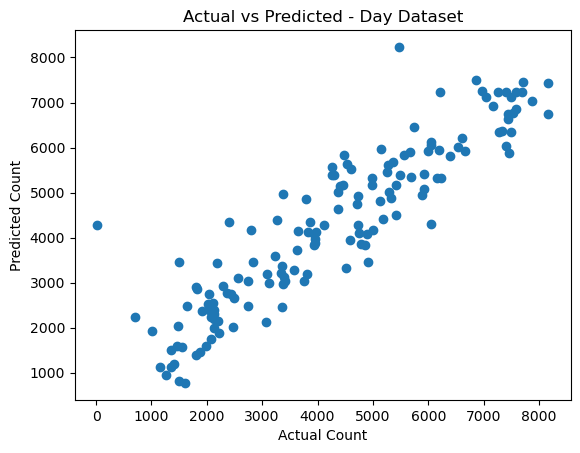

In [9]:
plt.figure()
plt.scatter(y_test_day, pred_day)
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted - Day Dataset")
plt.show()


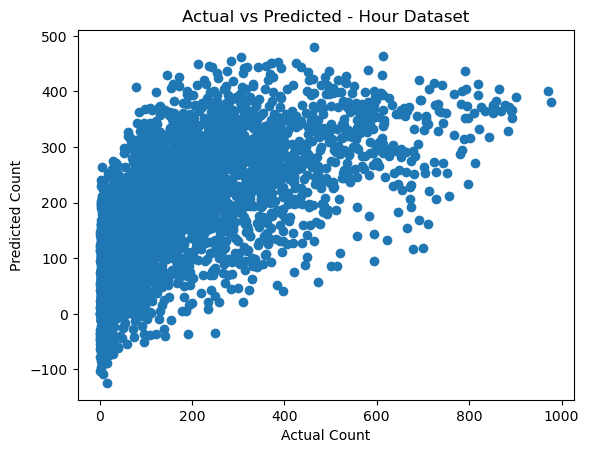

In [10]:
plt.figure()
plt.scatter(y_test_hour, pred_hour)
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted - Hour Dataset")
plt.show()
